In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba

from molsim import mullerBrownPotential, mullerBrownPotentialAndGradient, plot_muller_brown_heatmap

<div style="max-width: 1000px; margin: auto; margin-left: 0; font-size: 20px; line-height: 1.6;">

#  Exercise 1: Müller-Brown potential
The Müller-Brown (MB) potential is a two-dimensional model potential energy surface that was designed for illustrative purposes rather than being derived from a physical system [1]. It features three minima and two saddle points, which are described mathematically as follows:

$$
    v(x, y) = \sum_{k=0}^3 A_k \exp{\left[\alpha_k(x - a_k)^2 + \beta_k(x - a_k)(y - b_k) + \gamma_k(y - b_k)^2\right]},

$$
with the original constants of

$A = [-200, -100, -170, 15]$, 

$\alpha = [-1, -1, -6.5, 0.7]$,

 $\beta = [0, 0, 11, 0.6]$, 

 $\gamma = [-10, -10, -6.5, 0.7]$, 

 $a = [1, 0, -0.5, -1.0]$ 
 
 and $b = [0, 0.5, 1.5, 1]$. 


This potential energy surface is continuous, smooth, and differentiable, making it particularly useful for testing and demonstrating computational methods. Its well-defined structure, characterized by multiple minima and saddle points, is ideal for benchmarking techniques that involve free-energy calculations or exploring transition pathways.

##### Reference
[1] Müller K, Brown LD. Location of saddle points and minimum energy paths by a constrained simplex optimization procedure. Theoretica Chimica Acta. 1979;53:75-9

</div>

In [ ]:
plot_muller_brown_heatmap()

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## **Implement the Velocity Verlet Integrator**

The velocity Verlet integrator is a deterministic scheme used to integrate Newton's equations of motion. 
Given the same initial conditions, the results are fully reproducible as no randomness is introduced.

- It is ideal for NVE simulations (microcanonical ensemble) where energy is conserved.
- Combined with a Nose-Hoover thermostat, it can also be used for NVT simulations (canonical ensemble) in a deterministic fashion.

The position $\mathbf{r}$ and velocity $\mathbf{v}$ are updated as follows:

1. **First Velocity Update**:  
   $$
   \mathbf{v}\left(t + \frac{\Delta t}{2}\right) = \mathbf{v}(t) + \frac{1}{2} \mathbf{f}(t) \Delta t
   $$

2. **Position Update**:  
   $$
   \mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}\left(t + \frac{\Delta t}{2} \right) \Delta t
   $$

3. **Force Update**:
   $$
   \mathbf{fa}(t + \Delta t) = -\frac{\partial \mathcal{U}}{\partial \mathbf{r}}
   $$
   where $\mathbf{f}(t)$ is the force at time $t$, defined as the **negative gradient of the potential energy**.

4. **Velocity Update (Two steps)**:
   $$
   \mathbf{v}(t + \Delta t) = \mathbf{v}\left(t + \frac{\Delta t}{2}\right) + \frac{1}{2} \mathbf{f}(t + \Delta t) \Delta t
   $$

5. **Total Energy**:  
   Compute the total energy at each step as:  
   $$
   E_{\text{total}} = E_{\text{potential}} + E_{\text{kinetic}}, \quad \text{where} \, E_{\text{kinetic}} = \frac{1}{2} |\mathbf{v}|^2
   $$

---

## **Task**

Your goal is to implement the **velocity Verlet integrator** inside the function template provided below. The function should output:
1. The **trajectory** of the particle positions.
2. The **total**, **potential** and **kinetic energy** of the system at each time step.

The 2D potential field is described by the **Müller-Brown potential**. You can use the provided function `mullerBrownPotentialAndGradient` to compute the potential energy and its gradient.

---

## **Function Template**

You are provided with a function template in the python cell below. Complete the missing parts based on the velocity Verlet equations.

---

## **Step-by-Step Instructions**

1. **Initialization**:
   - Use `mullerBrownPotentialAndGradient` to calculate the initial potential energy and force for the starting position. 
   The simulation is initialized at the same starting position every time. At these coordinates $(x_{init},y_{init})=(-0.557114228, 1.44889779)$ the potential energy is $U_{MB}(x_{init},y_{init})\approx -146.66$.

   - Initialize the velocity with a random direction and a magnitude given by an initial kinetic energy. A random number generator seed is added to the ```velocityVerlet``` function such that you can compare to the expected results.

2. **Implement the Loop**:
   - Update the **velocity** by a half step using the force.
   - Update the **position** using the position equation.
   - Recalculate the **potential energy** and **force** at the updated position.
   - Update the **velocity** by a half step.
   - Compute the **total energy** (potential + kinetic) and store it.

3. **Validation**:
   - Run the function with small parameters, such as:
     ```python
     numberOfCycles = 50000
     initialKineticEnergy = 110
     timeStep = 5e-4
     seed = 50
     ```
   - Plot the particle trajectory and total energy to visualize the behavior.

---

## **Hints**

- Use the function `mullerBrownPotentialAndGradient` to compute the potential energy and gradient:  
   ```python
    potentialEnergy, gradient_dx, gradient_dy = mullerBrownPotentialAndGradient(positions[0])
    force = -np.array([gradient_dx, gradient_dy])  # Force is the negative gradient of the potential
   ```

- Initialize the velocity as:  
   ```python
    # Initialize velocity with a random direction
    theta = 2 * np.pi * np.random.rand()  # Random angle in radians
    velocity = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)  # Unit vector in random direction

    # Scale velocity magnitude to ensure the correct initial kinetic energy
    velocity *= np.sqrt(2 * initialKineticEnergy)  
   ```

- Use the following to compute the kinetic energy:  
   ```python
   # Define a lambda function to compute the kinetic energy of the particle
   computeKineticEnergy = lambda v: 0.5 * np.sum(v**2)  # K.E. = 0.5 * |velocity|^2
   ```

---

## **Expected Output**

When implemented correctly:
1. The **positions** array will contain the particle trajectory over time.
2. The **energies** array will show how the total energy evolves at each time step.


When implemented correctly using the settings for validation the total energy evolution and trajectory shown on the 2d potential heatmap should look as follows.
Initializing with a specific kinetic energy the total/conserved energy will be $E_{\text{total}} = U_{MB}(x_{init},y_{init}) + E_{\text{kinetic}}$. 

<div style="max-width:600px;margin-right: auto; margin-right: 0;">

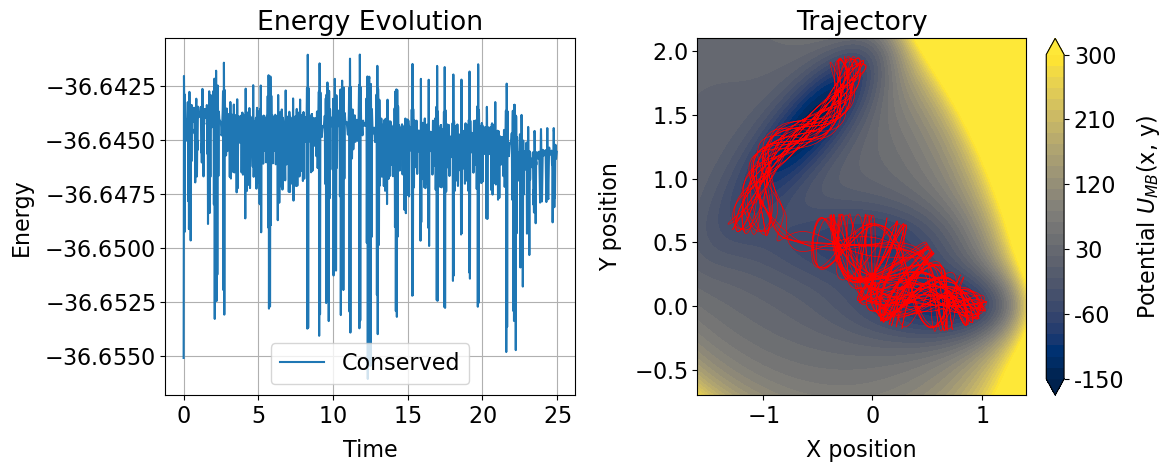

</div>


In [ ]:
@numba.njit
def velocityVerlet(numberOfCycles: int, initialKineticEnergy: float, timeStep: float = 5e-4, seed: int = 0):
    """
    Implements the velocity Verlet integrator to simulate the motion of a particle
    in a 2D potential field (Müller-Brown potential).

    Parameters:
        numberOfCycles (int): Total number of integration steps.
        initialKineticEnergy (float): Initial kinetic energy of the system at initial setup (initial condition).
        timeStep (float): Time step for integration (default is 5e-4).
        seed (int): Seed for random number generation (default is 0, no seed).

    Returns:
        positions (np.ndarray): Array storing particle positions at each step.
        energies (np.ndarray): Array storing total energy (potential + kinetic) at each step.
    """
    # Set a random seed for reproducibility if specified
    if seed != 0:
        np.random.seed(seed)
    # Initialize arrays to store positions and energies
    positions = np.zeros((numberOfCycles, 2), dtype=np.float32)  # Position array: (steps, x/y coordinates)
    energies = np.zeros(
        (numberOfCycles, 3), dtype=np.float32
    )  # Energy array: total energy ,potential energy and kinetic energy at each step

    # Fix the initial position of the particle
    positions[0] = np.array([-0.557114228, 1.44889779])

    # start refactor
    # Compute the initial potential energy and force at the starting position
    # Initialize velocity with a random direction
    # Scale velocity magnitude to ensure the correct initial kinetic energy
    # Define a lambda function to compute the kinetic energy of the particle
    # Compute the total initial energy (potential + kinetic)
    # end refactor

    # # Main loop to integrate over the number of cycles
    for cycle in range(1, numberOfCycles):
        # start refactor
        # Update velocity halfway using the force at the current step:
        # v(t + dt/2) = v(t) + 0.5 * F(t) * dt
        # Update position using the velocity Verlet position equation:
        # r(t + dt) = r(t) + v(t + dt/2) * dt
        # Recompute potential energy and force at the updated position
        # Complete the velocity update:
        # v(t + dt) = v(t + dt/2) + 0.5 * F(t + dt) * dt
        # Compute and store the total energy at this step
        # remove this pass
        pass
    # end refactor

    # Return the arrays containing positions and energies
    return positions, energies

In [ ]:
# Run simulation
timeStep = 5e-4
pos, energies = velocityVerlet(50000, 110, seed=50, timeStep=timeStep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot energy evolution
ax1.plot(np.arange(len(energies)) * timeStep, energies[:, 0], label="Conserved")
# ax1.plot(np.arange(len(energies)) * timeStep, energies[:,1], label="Potential")
# ax1.plot(np.arange(len(energies)) * timeStep, energies[:,2], label="Kinetic")
ax1.set_title("Energy Evolution")
ax1.set_xlabel(r"Time / $\tau$")
ax1.set_ylabel(r"Energy / $\varepsilon$")
ax1.legend()

# Plot trajectory
plot_muller_brown_heatmap(ax2)
ax2.plot(*pos[::10].T, lw=0.5, c="red")
ax2.set_title("Trajectory")
ax2.set_xlabel("X position")
ax2.set_ylabel("Y position")

fig.tight_layout()
plt.show()

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## Question 2
Run the velocity Verlet simulation to generate **8 trajectories**, each with a different initial kinetic energy. Plot the trajectories on a Muller-Brown potential heatmap, arranging the plots in a \( 2 $\times$ 4 \) grid. Observe how the trajectories differ and identify the minimum kinetic energy required for transitions between minima.
Can you see interesting anomilies when performing multiple simulations at the same energy. 

In [ ]:
# Simulate multiple runs with different total energies
timeStep = 5e-4
numSteps = 50000
energiesTest = [20, 40, 60, 80, 100, 120, 140, 160]
nRuns = 10

# Plot the trajectories for each total energy
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()
colors = [
    "red",
    "cyan",
    "magenta",
    "lime",
    "orange",
    "darkviolet",
    "pink",
    "black",
]
for i, initialKineticEnergy in enumerate(energiesTest):
    plot_muller_brown_heatmap(axes[i])
    for j in range(nRuns):
        pos, _ = velocityVerlet(numSteps, initialKineticEnergy, timeStep=timeStep)
        axes[i].plot(*pos[::10].T, lw=0.5, alpha=0.6, c=colors[j % len(colors)])
        axes[i].set_title(f"Initial Kinetic Energy = {initialKineticEnergy}")

fig.tight_layout()
plt.show()

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

### Question 3
Analyze the speed of the particle. Plot a distribution of the speed and compare it to the Maxwell-Boltzmann distribution. Does the system follow the Maxwell-Boltzmann distribution? Explain any deviations.

In [ ]:
# Simulate velocity Verlet for 1 million steps
_, energies = velocityVerlet(int(1e6), 80, timeStep=5e-4, seed=30)

Temperature = np.mean(energies[:, 2])  # Temperature from Kinetic energy (in 2D <E_K>= T)
beta = 1 / Temperature  # Reduced units (k_B = 1)

# Compute speeds from kinetic energies
speeds = np.sqrt(2 * energies[:, 2])

# Generate theoretical Maxwell-Boltzmann distribution
v = np.linspace(0, np.max(speeds), 500)
maxwellBoltzmannDistribition = beta * v * np.exp(-0.5 * beta * v**2)  # Maxwell-Boltzmann distribution for a 2d system

# Plot simulated vs theoretical
plt.figure(figsize=(8, 5))
plt.hist(speeds, bins=200, density=True, label="Simulated")
plt.plot(v, maxwellBoltzmannDistribition, "r--", label="Maxwell-Boltzmann (2D)")
plt.xlabel("Speed")
plt.ylabel("Probability Density")
plt.title("Maxwell-Boltzmann Distribution in 2D")
plt.legend()
plt.show()